# Chapter 112 — Translation

> **Prerequisites:** ch108 (Transformations)
>
> **Outcomes:** Represent translation as vector addition; Understand why translation isn't a linear map in standard form; Introduce homogeneous coordinates


## Translation

**Translation** moves all points by a fixed vector (dx, dy):
x' = x + dx
y' = y + dy

**The problem:** This is NOT a linear map. A linear map must satisfy f(0) = 0.
But translation moves the origin: (0,0) → (dx, dy) ≠ (0,0) if (dx,dy) ≠ 0.

So translation cannot be represented as a 2×2 matrix multiplication.

**Solution: Homogeneous coordinates.**
Represent a 2D point (x, y) as a 3D vector [x, y, 1].

Then translation becomes a matrix:
T(dx, dy) = [[1, 0, dx], [0, 1, dy], [0, 0, 1]]

Check: T · [x, y, 1]ᵀ = [x+dx, y+dy, 1]ᵀ ✓

This is why computer graphics uses 4×4 matrices for 3D transforms — the same trick in 3D.

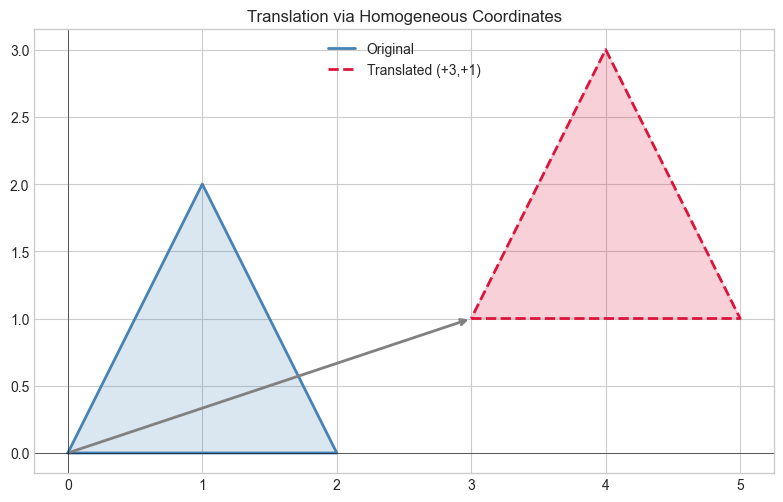

Translation matrix T(3,1):
[[1. 0. 3.]
 [0. 1. 1.]
 [0. 0. 1.]]
Applied to (0,0,1): [3. 1. 1.]


In [2]:
# --- Homogeneous coordinates and translation ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def to_homogeneous(pts):
    """Add homogeneous coordinate: (N,2) → (N,3)."""
    return np.hstack([pts, np.ones((len(pts),1))])

def from_homogeneous(pts_h):
    """Remove homogeneous coordinate, normalize."""
    return pts_h[:,:2] / pts_h[:,2:3]

def translation_matrix(dx, dy):
    """3×3 homogeneous translation matrix."""
    return np.array([[1,0,dx],[0,1,dy],[0,0,1]], dtype=float)

def rotation_matrix_h(theta):
    """3×3 homogeneous rotation matrix."""
    c,s = np.cos(theta), np.sin(theta)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=float)

def scale_matrix_h(sx, sy):
    """3×3 homogeneous scale matrix."""
    return np.array([[sx,0,0],[0,sy,0],[0,0,1]], dtype=float)

# Shape
triangle = np.array([[0,0],[2,0],[1,2]], dtype=float)
tri_h = to_homogeneous(triangle)

T = translation_matrix(3, 1)
translated = from_homogeneous((T @ tri_h.T).T)

fig, ax = plt.subplots(figsize=(8, 5))
closed = lambda p: np.vstack([p, p[0]])
ax.fill(triangle[:,0], triangle[:,1], alpha=0.2, color='steelblue')
ax.plot(closed(triangle)[:,0], closed(triangle)[:,1], 'steelblue', lw=2, label='Original')
ax.fill(translated[:,0], translated[:,1], alpha=0.2, color='crimson')
ax.plot(closed(translated)[:,0], closed(translated)[:,1], 'crimson', lw=2, linestyle='--', label='Translated (+3,+1)')
ax.annotate('', xy=translated[0], xytext=triangle[0],
            arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.set_aspect('equal'); ax.legend(); ax.set_title('Translation via Homogeneous Coordinates')
ax.axhline(0, color='k', linewidth=0.4); ax.axvline(0, color='k', linewidth=0.4)
plt.tight_layout(); plt.show()

print("Translation matrix T(3,1):")
print(T)
print("Applied to (0,0,1):", T @ np.array([0,0,1]))

## Summary

- Translation is NOT a linear map — origin doesn't stay at origin
- Homogeneous coordinates: represent (x,y) as [x,y,1]
- Translation as 3×3 matrix: T = [[1,0,dx],[0,1,dy],[0,0,1]]
- This is the standard trick in all computer graphics (OpenGL, DirectX, WebGL use 4×4 matrices)

**Forward:** ch114 (Affine Transformations) combines all four transforms in homogeneous coordinates.